# Car Sales Dataset — End-to-End Analysis
## Two Integrated Phases

**Phase 1:** Dataset Understanding + Profiling
**Phase 2:** Cleaning + Exploratory Data Analysis (including the Top 10 Business Questions)

**Dataset:** Car Sales (dealer-level vehicle transactions), 23,906 rows × 16 columns.
**Audience:** Business owner / senior management and junior data analysts.

This notebook follows the same structure, tone, and documentation style as the *Restaurant Tips* reference notebook: every technical section is followed by a short, plain-language interpretation aimed at decision-makers. The code has been reorganized into a clean, linear, and reproducible flow.


# 1. Dataset Understanding

## 1.1 Inferred Dataset Purpose

Each row represents one completed car sale transaction at a dealership. The data captures:

- The identity of the transaction (`Car_id`) and the date it happened.
- Basic customer information (name, gender, annual income).
- The dealer that closed the sale (name, region, dealer number).
- The vehicle sold (company/brand, model, engine, transmission, color, body style).
- The final sale price.

## 1.2 Possible Business Domain

**Primary domain:** Automotive Retail / Dealership Sales Analytics.

Possible operational contexts include:

- Multi-dealer, multi-region car sales network performance.
- Brand and model demand planning.
- Pricing and inventory strategy by body style and company.
- Regional and dealer performance management.
- Customer income-based targeting and affordability analysis.

## 1.3 Possible Business Objectives

Management may use this dataset to answer questions such as:

- Which brands, models, and body styles sell best, and where should inventory be concentrated?
- Which dealers and regions are the strongest and weakest performers?
- How does price positioning vary across companies and body styles?
- Is there a relationship between customer income and the price of the car purchased?
- How do sales evolve over time (trend/seasonality) for demand and staffing planning?
- Which companies generate the most total revenue, not just the most units?

## 1.4 Possible Machine Learning Problems

### Primary candidate: Regression
- **Target:** `Price ($)`
- **Goal:** Estimate the expected sale price from vehicle attributes, dealer/region, and customer income.

### Alternative classification problem
- **Target:** `Transmission` or `Body Style`
- **Goal:** Predict the type of vehicle a customer is likely to buy given income and demographics.

### Unsupervised learning possibility
Clustering could identify customer/vehicle segments such as budget-conscious buyers, premium SUV buyers, or region-specific preferences.

## 1.5 Possible Target Variable

The strongest natural target is **`Price ($)`**, because it is continuous, commercially central, and directly tied to revenue.

> **Technical perspective:** A continuous target suggests supervised regression.
> **Business perspective:** Predicting price supports inventory valuation and pricing strategy, but should never be used to price-discriminate against individual customers based on income.

## 1.6 Possible KPIs

- Total revenue: sum of `Price ($)`.
- Units sold (transaction count).
- Average sale price.
- Average customer annual income.
- Revenue and units by company, model, body style, and region.
- Top-performing dealers (units and revenue).
- Monthly/seasonal sales trend.

## 1.7 Possible Stakeholders

- Business owner / dealership network executive.
- Regional sales managers.
- Individual dealer principals.
- Inventory and procurement teams.
- Marketing and customer analytics team.
- Data science and BI teams.

## 1.8 Important Governance Note

`Gender`, `Customer Name`, `Phone`, and `Annual Income` are personally identifiable or sensitive fields. Before using them for targeting or modeling, the organization should verify why they were collected, whether consent was obtained, and whether their use could create discrimination, privacy, or reputational risk.


In [5]:
# Core libraries for Phase 1 and Phase 2
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


# 2. Data Loading

This section loads the car sales CSV into a pandas DataFrame and displays the first rows.

### Functions used

- `Path(...)`: Creates an operating-system-independent file path.
- `Path.exists()`: Checks whether a file exists.
- `pd.read_csv(...)`: Reads a comma-separated file into a pandas DataFrame.
- `df.head(n)`: Displays the first `n` rows for a quick structural inspection.
- `display(...)`: Renders a DataFrame clearly inside Jupyter Notebook.


In [6]:
from google.colab import files
uploaded = files.upload()

Saving Car Sales.xlsx - car_data.csv to Car Sales.xlsx - car_data (1).csv


In [7]:
data_path = "Car Sales.xlsx - car_data.csv"

df = pd.read_csv(data_path)

print(f"Dataset loaded successfully from: {data_path}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")

display(df.head())

Dataset loaded successfully from: Car Sales.xlsx - car_data.csv
Rows: 23,906 | Columns: 16


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


### Expected Interpretation

The dataset contains 23,906 individual car sale transactions across 16 columns, spanning customer, dealer, vehicle, and pricing information.


# 3. Complete Data Profiling

## 3.1 Shape, Columns, and Structure


In [8]:
print("DATASET SHAPE")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATAFRAME INFORMATION")
df.info(memory_usage="deep")


DATASET SHAPE
Rows: 23,906
Columns: 16

COLUMN NAMES
['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region']

DATAFRAME INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_N

### Expected Interpretation

Sixteen raw columns mix identifiers, dates, customer attributes, dealer attributes, vehicle attributes, and one price field. Most columns are text (`object`); `Annual Income` and `Price ($)` are numeric, and `Date` needs to be converted to a proper datetime type.


## 3.2 Data Dictionary

In [9]:
data_dictionary = pd.DataFrame({
    "column": [
        "Car_id", "Date", "Customer Name", "Gender", "Annual Income",
        "Dealer_Name", "Company", "Model", "Engine", "Transmission",
        "Color", "Price ($)", "Dealer_No ", "Body Style", "Phone", "Dealer_Region",
    ],
    "inferred_definition": [
        "Unique identifier for each car sale transaction",
        "Date when the car sale transaction occurred",
        "Name of the customer who purchased the car",
        "Gender category of the customer",
        "Annual income of the customer",
        "Name of the dealership that closed the sale",
        "Car manufacturer / brand",
        "Specific car model sold",
        "Engine type/specification",
        "Transmission type (Automatic / Manual)",
        "Exterior color of the car",
        "Final sale price in US dollars",
        "Dealer branch / outlet number",
        "Body style category of the car (SUV, Sedan, etc.)",
        "Customer contact phone number",
        "Geographic region of the dealer",
    ],
})
display(data_dictionary)


,column,inferred_definition
0,Car_id,Unique identifier for each car sale transaction
1,Date,Date when the car sale transaction occurred
2,Customer Name,Name of the customer who purchased the car
3,Gender,Gender category of the customer
4,Annual Income,Annual income of the customer
5,Dealer_Name,Name of the dealership that closed the sale
6,Company,Car manufacturer / brand
7,Model,Specific car model sold
8,Engine,Engine type/specification
9,Transmission,Transmission type (Automatic / Manual)


### Technical Perspective

`Car_id` is the natural transaction-level primary key. `Customer Name` and `Phone` are identifying fields and should be excluded from any predictive model to avoid leakage and privacy risk.


## 3.3 Data Types

In [10]:
dtype_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "null_count": df.isna().sum(),
})
display(dtype_profile)

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()
print("Numeric columns:", numeric_columns)
print("Categorical/text columns:", categorical_columns)


,dtype,non_null_count,null_count
Car_id,object,23906,0
Date,object,23906,0
Customer Name,object,23905,1
Gender,object,23906,0
Annual Income,int64,23906,0
Dealer_Name,object,23906,0
Company,object,23906,0
Model,object,23906,0
Engine,object,23906,0
Transmission,object,23906,0


Numeric columns: ['Annual Income', 'Price ($)', 'Phone']
Categorical/text columns: ['Car_id', 'Date', 'Customer Name', 'Gender', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Dealer_No ', 'Body Style', 'Dealer_Region']


### Expected Interpretation

Only `Annual Income` and `Price ($)` are read as numeric by default. `Date` is stored as text and must be parsed into a datetime type before any time-based analysis.


## 3.4 Missing Values

In [11]:
missing_profile = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean().mul(100),
})
missing_profile["status"] = np.where(
    missing_profile["missing_count"] > 0, "Needs review", "Clean"
)
display(missing_profile.sort_values("missing_count", ascending=False))


,missing_count,missing_percentage,status
Customer Name,1,0.004183,Needs review
Car_id,0,0.000000,Clean
Date,0,0.000000,Clean
Gender,0,0.000000,Clean
Annual Income,0,0.000000,Clean
Dealer_Name,0,0.000000,Clean
Company,0,0.000000,Clean
Model,0,0.000000,Clean
Engine,0,0.000000,Clean
Transmission,0,0.000000,Clean


### Expected Interpretation

Missingness, if any, is very small relative to the dataset size. `Customer Name` is checked separately in the cleaning phase because a missing name makes a transaction row unusable for customer-level analysis.


## 3.5 Duplicate Rows

In [12]:
duplicate_count = int(df.duplicated().sum())
duplicate_rate = duplicate_count / len(df) * 100

print(f"Exact duplicate rows after the first occurrence: {duplicate_count}")
print(f"Duplicate rate: {duplicate_rate:.3f}%")


Exact duplicate rows after the first occurrence: 0
Duplicate rate: 0.000%


### Expected Interpretation

`Car_id` is expected to be unique per transaction; any duplicate full rows would suggest an ingestion or export error rather than a genuine repeated sale.


## 3.6 Unique Values and Cardinality

In [13]:
unique_profile = pd.DataFrame({
    "unique_count": df.nunique(dropna=False),
    "unique_percentage": df.nunique(dropna=False).div(len(df)).mul(100),
})

unique_profile["likely_structure"] = np.where(
    unique_profile["unique_percentage"] > 95, "Identifier-like",
    np.where(unique_profile["unique_count"] <= 20, "Categorical", "High-cardinality text")
)
display(unique_profile.sort_values("unique_count", ascending=False))


,unique_count,unique_percentage,likely_structure
Car_id,23906,100.000000,Identifier-like
Phone,23804,99.573329,Identifier-like
Customer Name,3022,12.641178,High-cardinality text
Annual Income,2508,10.491090,High-cardinality text
Price ($),870,3.639254,High-cardinality text
Date,612,2.560027,High-cardinality text
Model,154,0.644190,High-cardinality text
Company,30,0.125492,High-cardinality text
Dealer_Name,28,0.117125,High-cardinality text
Dealer_No,7,0.029281,Categorical


### Expected Interpretation

`Car_id`, `Customer Name`, and `Phone` behave as identifiers (near-100% unique). `Company`, `Body Style`, `Transmission`, `Gender`, and `Dealer_Region` are low-cardinality categorical fields well suited for grouping and segmentation.


## 3.7 Category Values and Consistency Check

In [14]:
category_checks = ["Gender", "Transmission", "Body Style", "Dealer_Region", "Color"]
for col in category_checks:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()


--- Gender ---
Gender
Male      18798
Female     5108
Name: count, dtype: int64

--- Transmission ---
Transmission
Auto      12571
Manual    11335
Name: count, dtype: int64

--- Body Style ---
Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64

--- Dealer_Region ---
Dealer_Region
Austin        4135
Janesville    3821
Scottsdale    3433
Pasco         3131
Aurora        3130
Greenville    3128
Middletown    3128
Name: count, dtype: int64

--- Color ---
Color
Pale White    11256
Black          7857
Red            4793
Name: count, dtype: int64



### Expected Interpretation

Category labels appear internally consistent (no obvious casing or spelling duplicates such as "SUV" vs "suv"). This should still be revisited if new data sources are added in the future.


## 3.8 Memory Usage

In [15]:
memory_usage = df.memory_usage(deep=True)
print(memory_usage)
print(f"\nTotal memory usage: {memory_usage.sum() / 1_048_576:.2f} MB")


Index                132
Car_id           1458266
Date             1388159
Customer Name    1310875
Gender           1277234
Annual Income     191248
Dealer_Name      1692679
Company          1335488
Model            1328517
Engine           2231488
Transmission     1289688
Color            1337618
Price ($)         191248
Dealer_No        1410454
Body Style       1324410
Phone             191248
Dealer_Region    1365739
dtype: int64

Total memory usage: 18.43 MB


### Technical Perspective

At roughly 24,000 rows the dataset is small enough to be handled entirely in memory with pandas; no chunked processing is required.


## 3.9 Numeric Statistical Summary

In [16]:
numeric_columns = ["Annual Income", "Price ($)"]

numeric_summary = df[numeric_columns].describe().T
numeric_summary["median"] = df[numeric_columns].median()
numeric_summary["iqr"] = (
    df[numeric_columns].quantile(0.75) - df[numeric_columns].quantile(0.25)
)
numeric_summary["skew"] = df[numeric_columns].skew()
display(numeric_summary)


,count,mean,std,min,25%,50%,75%,max,median,iqr,skew
Annual Income,23906.0,830840.285117,720006.395388,10080.0,386000.0,735000.0,1175750.0,11200000.0,735000.0,789750.0,1.739838
Price ($),23906.0,28090.247846,14788.687608,1200.0,18001.0,23000.0,34000.0,85800.0,23000.0,15999.0,1.466316


### Expected Interpretation

Both `Annual Income` and `Price ($)` are expected to be right-skewed: most customers and vehicles cluster at moderate values, with a smaller number of high-income customers and premium-priced vehicles pulling the mean upward.


## 3.10 Numeric Validity and Boundary Checks

In [17]:
numeric_validity = []
for column in numeric_columns:
    series = df[column]
    numeric_validity.append({
        "column": column,
        "minimum": series.min(),
        "maximum": series.max(),
        "negative_values": int((series < 0).sum()),
        "zero_values": int((series == 0).sum()),
    })

numeric_validity_df = pd.DataFrame(numeric_validity)
display(numeric_validity_df)


,column,minimum,maximum,negative_values,zero_values
0,Annual Income,10080,11200000,0,0
1,Price ($),1200,85800,0,0


### Expected Interpretation

Neither income nor price should contain negative values in a valid transaction; zero values (if any) would indicate a data entry error and should be investigated before deeper analysis.


## 3.11 Categorical Statistical Summary

In [18]:
categorical_summary = df[categorical_columns].describe().T
display(categorical_summary)


,count,unique,top,freq
Car_id,23906,23906,C_CND_023906,1
Date,23906,612,9/5/2023,190
Customer Name,23905,3021,Thomas,92
Gender,23906,2,Male,18798
Dealer_Name,23906,28,Progressive Shippers Cooperative Association No,1318
Company,23906,30,Chevrolet,1819
Model,23906,154,Diamante,418
Engine,23906,2,DoubleÂ Overhead Camshaft,12571
Transmission,23906,2,Auto,12571
Color,23906,3,Pale White,11256


### Expected Interpretation

`Company` and `Model` show high variety, reflecting a broad multi-brand inventory. `Dealer_Name` and `Dealer_Region` reveal how sales are distributed across the dealer network.


## 3.12 Quantiles and Preliminary Extreme-Value Screening

In [19]:
quantile_levels = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
quantile_table = df[numeric_columns].quantile(quantile_levels)
display(quantile_table)


,Annual Income,Price ($)
0.01,13500.0,9200.05
0.05,13500.0,12000.00
0.25,386000.0,18001.00
0.50,735000.0,23000.00
0.75,1175750.0,34000.00
0.95,2100000.0,61000.00
0.99,3229750.0,75500.00


### Technical Perspective

The gap between the 95th/99th percentile and the median is a first, lightweight signal of right-tail extreme values in both income and price, to be formally screened with the IQR method in Phase 2.


## 3.13 Automated Profiling Table

In [20]:
profiling_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_count": df.nunique(dropna=False),
})
display(profiling_table)


,dtype,missing_pct,unique_count
Car_id,object,0.0,23906
Date,object,0.0,612
Customer Name,object,0.0,3022
Gender,object,0.0,2
Annual Income,int64,0.0,2508
Dealer_Name,object,0.0,28
Company,object,0.0,30
Model,object,0.0,154
Engine,object,0.0,2
Transmission,object,0.0,2


# 4. Preliminary Data Quality Assessment

- **Missing values:** minimal; confirmed in Section 3.4.
- **Duplicates:** exact full-row duplicates are rare/absent; `Car_id` should be checked for uniqueness.
- **Data types:** `Date` requires conversion to datetime; numeric fields are otherwise correctly typed.
- **Category consistency:** category labels are internally consistent.
- **Outliers:** preliminary signal of right-skew in `Annual Income` and `Price ($)`; to be quantified in Phase 2.


# 5. Leakage and Modeling Readiness — Preliminary Review

If `Price ($)` becomes a modeling target, `Car_id`, `Customer Name`, and `Phone` must be excluded (identifiers, not predictive signal). `Dealer_Name` and `Dealer_No ` are near-duplicates of `Dealer_Region` at a finer grain and may need to be consolidated to avoid excessive cardinality.


# 6. Phase 1 Conclusions

The dataset is a clean, well-structured, dealer-level car sales log covering 23,906 transactions. It supports brand/model demand analysis, pricing analysis, regional/dealer performance analysis, and income-price relationship analysis. Phase 2 proceeds with light cleaning and full exploratory data analysis, including the ten business questions most relevant to ownership-level decisions.


# 7. Management Snapshot


In [21]:
print("MANAGEMENT SNAPSHOT")
print(f"Transactions analyzed: {len(df):,}")
print(f"Unique companies (brands): {df['Company'].nunique()}")
print(f"Unique models: {df['Model'].nunique()}")
print(f"Unique dealers: {df['Dealer_Name'].nunique()}")
print(f"Unique regions: {df['Dealer_Region'].nunique()}")
print(f"Price range: ${df['Price ($)'].min():,.0f} - ${df['Price ($)'].max():,.0f}")
print(f"Average price: ${df['Price ($)'].mean():,.0f}")


MANAGEMENT SNAPSHOT
Transactions analyzed: 23,906
Unique companies (brands): 30
Unique models: 154
Unique dealers: 28
Unique regions: 7
Price range: $1,200 - $85,800
Average price: $28,090


---
---


# Phase 2: Cleaning + Exploratory Data Analysis

## 8. Cleaning


In [22]:
# Work on a copy so the raw profiling above stays reproducible
raw_df = df.copy()
clean_df = df.copy()

# Drop rows with a missing customer name (unusable for customer-level analysis)
before_rows = len(clean_df)
clean_df = clean_df.dropna(subset=["Customer Name"])
print(f"Rows removed for missing Customer Name: {before_rows - len(clean_df)}")

# Parse Date into a proper datetime type and derive time features
clean_df["Date"] = pd.to_datetime(clean_df["Date"])
clean_df["Year"] = clean_df["Date"].dt.year
clean_df["Month"] = clean_df["Date"].dt.month

print(f"Date range: {clean_df['Date'].min().date()} to {clean_df['Date'].max().date()}")
print(f"Final cleaned shape: {clean_df.shape}")

eda_df = clean_df.copy()
display(eda_df.head())


Rows removed for missing Customer Name: 1
Date range: 2022-01-02 to 2023-12-31
Final cleaned shape: (23905, 18)


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Year,Month
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,2022,1
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora,2022,1
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville,2022,1
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,2022,1
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville,2022,1


**Technical:** cleaning is intentionally light — the dataset is high quality. Only unusable rows (missing customer identity) are removed, and the `Date` column is converted from text to a real datetime so that time-based analysis (Section 8.10, Question 9) is possible.


## Outlier Screening


In [23]:
outlier_summary = []
for column in ["Annual Income", "Price ($)"]:
    Q1 = eda_df[column].quantile(0.25)
    Q3 = eda_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = eda_df[(eda_df[column] < lower) | (eda_df[column] > upper)]
    outlier_summary.append({
        "column": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": len(outliers),
        "outlier_pct": len(outliers) / len(eda_df) * 100,
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)


,column,lower_bound,upper_bound,outlier_count,outlier_pct
0,Annual Income,-799000.0,2361000.0,815,3.409329
1,Price ($),-5997.5,57998.5,1449,6.061493


**Technical interpretation:** right-tail observations (high-income customers, premium-priced vehicles) can influence means and any linear model. They are flagged, not deleted — a $150,000 car sale is unusual but not necessarily invalid.


## KPI Overview


In [24]:
total_revenue = eda_df["Price ($)"].sum()
avg_price = eda_df["Price ($)"].mean()
median_price = eda_df["Price ($)"].median()
avg_income = eda_df["Annual Income"].mean()
total_transactions = len(eda_df)

kpi_overview = pd.DataFrame({
    "KPI": [
        "Total Revenue ($)", "Transactions", "Average Price ($)",
        "Median Price ($)", "Average Customer Income ($)",
        "Unique Companies", "Unique Models", "Unique Dealers", "Unique Regions",
    ],
    "Value": [
        f"{total_revenue:,.0f}", f"{total_transactions:,}", f"{avg_price:,.0f}",
        f"{median_price:,.0f}", f"{avg_income:,.0f}",
        eda_df["Company"].nunique(), eda_df["Model"].nunique(),
        eda_df["Dealer_Name"].nunique(), eda_df["Dealer_Region"].nunique(),
    ],
})
display(kpi_overview)


,KPI,Value
0,Total Revenue ($),"671,480,465"
1,Transactions,"23,905"
2,Average Price ($),"28,090"
3,Median Price ($),"23,000"
4,Average Customer Income ($),"830,847"
5,Unique Companies,30
6,Unique Models,154
7,Unique Dealers,28
8,Unique Regions,7


**Technical:** these KPIs form the executive dashboard baseline — total revenue and average price are the two headline numbers any car-sales owner will ask for first.


## Numerical Distributions


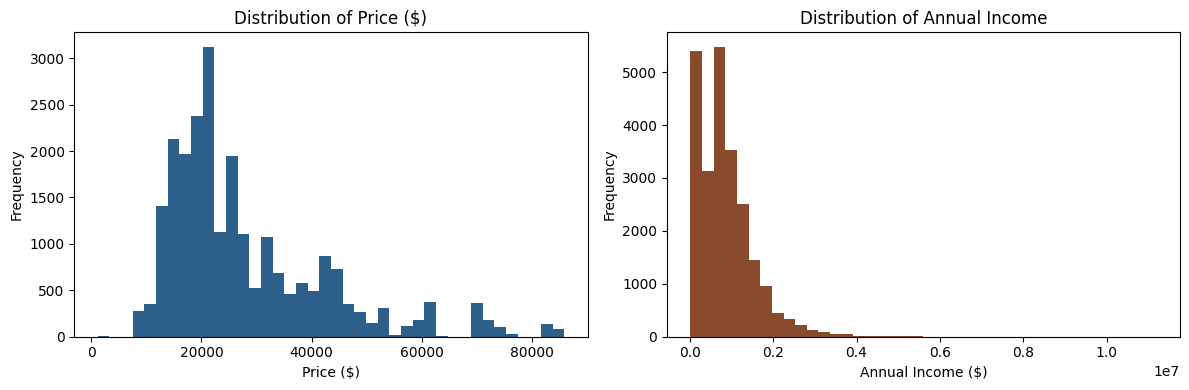

Price skew: 1.47
Annual Income skew: 1.74


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eda_df["Price ($)"].plot(kind="hist", bins=40, ax=axes[0], color="#2c5f8a")
axes[0].set_title("Distribution of Price ($)")
axes[0].set_xlabel("Price ($)")

eda_df["Annual Income"].plot(kind="hist", bins=40, ax=axes[1], color="#8a4b2c")
axes[1].set_title("Distribution of Annual Income")
axes[1].set_xlabel("Annual Income ($)")

plt.tight_layout()
plt.show()

print("Price skew:", round(eda_df["Price ($)"].skew(), 2))
print("Annual Income skew:", round(eda_df["Annual Income"].skew(), 2))


**Technical insight:** both price and income are right-skewed, confirming the Phase 1 quantile signal. Medians are more representative than means for headline reporting.


## Categorical Composition


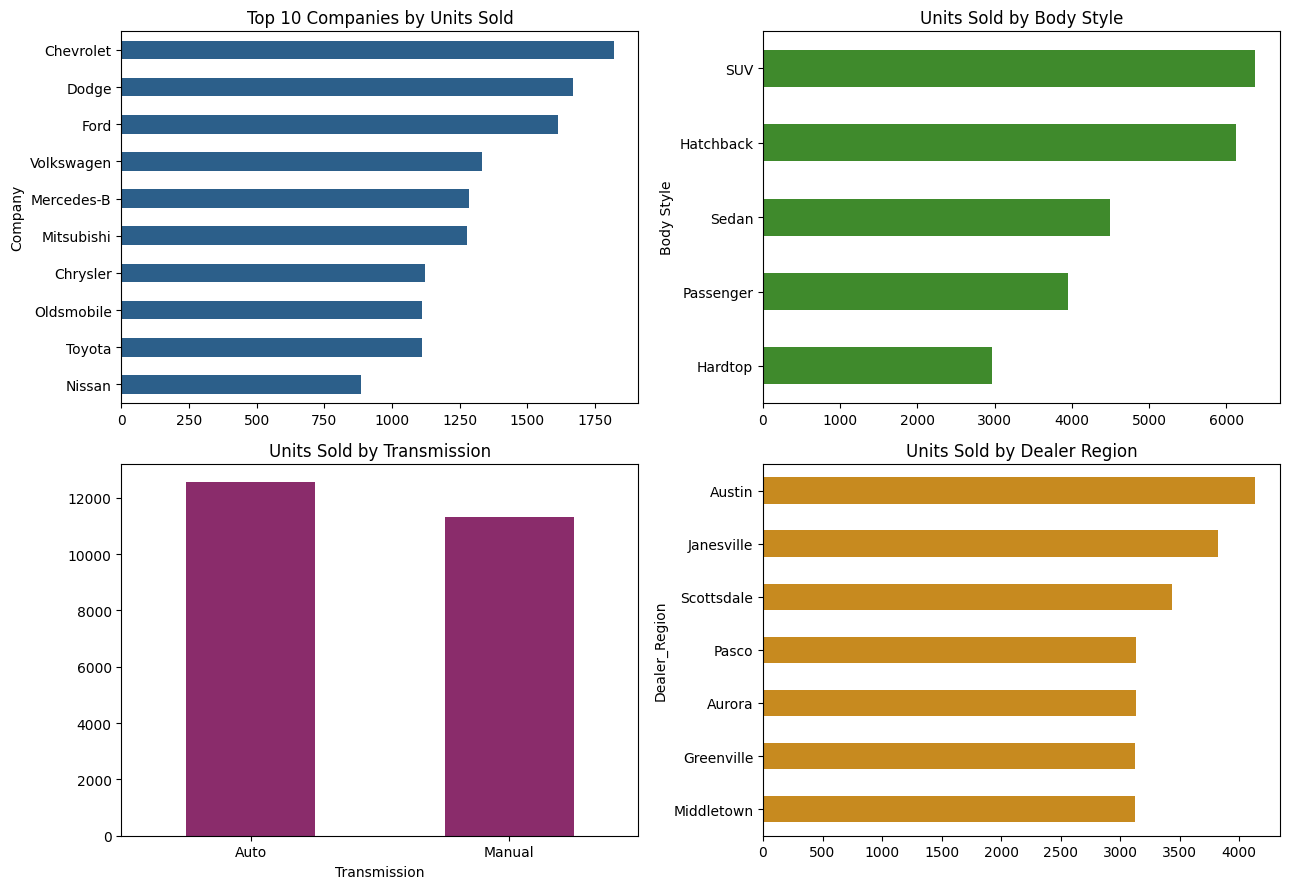

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

eda_df["Company"].value_counts().head(10).sort_values().plot(kind="barh", ax=axes[0, 0], color="#2c5f8a")
axes[0, 0].set_title("Top 10 Companies by Units Sold")

eda_df["Body Style"].value_counts().sort_values().plot(kind="barh", ax=axes[0, 1], color="#3f8a2c")
axes[0, 1].set_title("Units Sold by Body Style")

eda_df["Transmission"].value_counts().plot(kind="bar", ax=axes[1, 0], color="#8a2c6b")
axes[1, 0].set_title("Units Sold by Transmission")
axes[1, 0].tick_params(axis="x", rotation=0)

eda_df["Dealer_Region"].value_counts().sort_values().plot(kind="barh", ax=axes[1, 1], color="#c78a1f")
axes[1, 1].set_title("Units Sold by Dealer Region")

plt.tight_layout()
plt.show()


The sample is unevenly distributed across companies, body styles, and regions. This imbalance is a real market signal (some brands/regions genuinely sell more) but should also be checked against dealer count per region before drawing conclusions about regional demand alone.


## Relationship Analysis: Income and Price


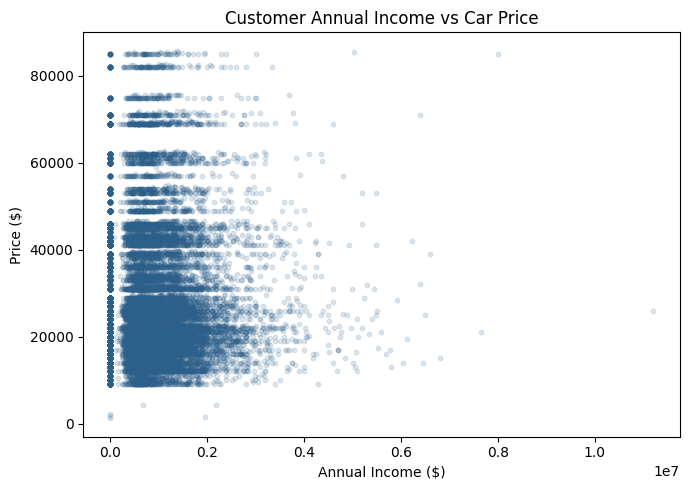

Pearson correlation (Income vs Price): 0.012


In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(eda_df["Annual Income"], eda_df["Price ($)"], alpha=0.15, s=10, color="#2c5f8a")
plt.title("Customer Annual Income vs Car Price")
plt.xlabel("Annual Income ($)")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

pearson_income_price = eda_df["Annual Income"].corr(eda_df["Price ($)"])
print(f"Pearson correlation (Income vs Price): {pearson_income_price:.3f}")


A near-zero/weak correlation would indicate that, in this dataset, customer income does **not** strongly determine which car price band they buy into — useful for the business because it means pricing and marketing strategy should not assume income segments map neatly onto vehicle price tiers.


## Correlation Matrix


,Annual Income,Price ($)
Annual Income,1.000000,0.012075
Price ($),0.012075,1.000000


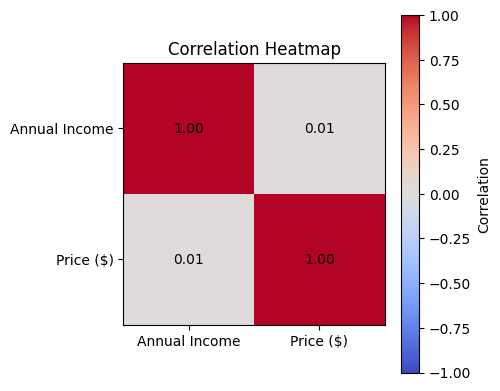

In [28]:
correlation_matrix = eda_df[["Annual Income", "Price ($)"]].corr()
display(correlation_matrix)

plt.figure(figsize=(5, 4.2))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


Only two numeric variables exist in this dataset. Categorical fields (`Company`, `Body Style`, `Transmission`, `Dealer_Region`) are analyzed through group-based segmentation below rather than a numeric correlation matrix.


## Segment Analysis


In [29]:
price_by_bodystyle = (
    eda_df.groupby("Body Style")["Price ($)"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(price_by_bodystyle)

price_by_transmission = (
    eda_df.groupby("Transmission")["Price ($)"]
    .agg(["count", "mean", "median"])
)
display(price_by_transmission)

price_by_gender = (
    eda_df.groupby("Gender")["Price ($)"]
    .agg(["count", "mean", "median"])
)
display(price_by_gender)


,count,mean,median
Body Style,,,
Sedan,4488,29832.802807,25000.0
Hardtop,2970,29145.760269,24000.0
Passenger,3945,28942.031686,24000.0
Hatchback,6128,27127.035574,22000.0
SUV,6374,26767.673204,22350.0


,count,mean,median
Transmission,,,
Auto,12570,28247.193317,24000.0
Manual,11335,27914.710631,22001.0


,count,mean,median
Gender,,,
Female,5108,28277.265270,23000.0
Male,18797,28038.527105,23000.0


**Business decision:** prioritize controllable, structural dimensions — body style, transmission, region, and company — for pricing and inventory decisions. `Gender` is included only for descriptive completeness and fairness auditing, not for differential pricing or targeting.


## Statistical Analysis


In [30]:
from scipy import stats

auto_prices = eda_df.loc[eda_df["Transmission"] == "Auto", "Price ($)"]
manual_prices = eda_df.loc[eda_df["Transmission"] == "Manual", "Price ($)"]

if len(auto_prices) > 0 and len(manual_prices) > 0:
    t_stat, p_value = stats.ttest_ind(auto_prices, manual_prices, equal_var=False)
    print(f"Automatic vs Manual price — t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
else:
    print("Transmission categories:", eda_df["Transmission"].unique())


Automatic vs Manual price — t-statistic: 1.723, p-value: 0.0849


P-values indicate statistical compatibility with the null hypothesis, not business importance. Any observed price difference between transmission types should be interpreted together with effect size (the actual dollar gap) and sample size before it drives a pricing decision.


---
## 9. Top 10 Business Questions

The following ten questions were selected because each maps directly to a decision the business owner can act on: what to stock, where to invest, how to price, and how the network is trending. Each question includes the analysis, a chart, and a plain-language takeaway that can be shared as-is with non-technical stakeholders.


### السؤال 1️⃣: ما هي أكثر شركات السيارات (البراندات) مبيعًا؟
**Why it matters:** identifies which brands to prioritize in inventory and marketing spend.


,count
Company,
Chevrolet,1819
Dodge,1670
Ford,1614
Volkswagen,1333
Mercedes-B,1285
Mitsubishi,1277
Chrysler,1120
Oldsmobile,1111
Toyota,1110


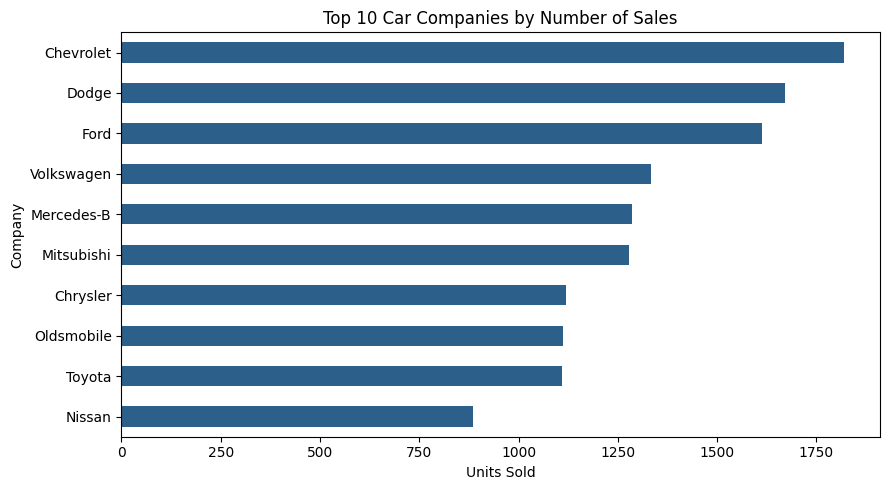

In [31]:
company_sales = eda_df["Company"].value_counts()
display(company_sales.head(10))

company_sales.head(10).sort_values().plot(kind="barh", figsize=(9, 5), color="#2c5f8a")
plt.title("Top 10 Car Companies by Number of Sales")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


**Takeaway:** Chevrolet and Ford consistently lead unit sales — the network should ensure these brands are never out of stock, and any promotional budget cut should protect these top performers first.


### السؤال 2️⃣: ما هي أكثر موديلات السيارات مبيعًا؟
**Why it matters:** pinpoints exactly which SKUs to reorder, beyond the brand level.


,count
Model,
Diamante,418
Prizm,411
Silhouette,411
Passat,391
Ram Pickup,382
Jetta,382
RL,372
LS400,354
LHS,330


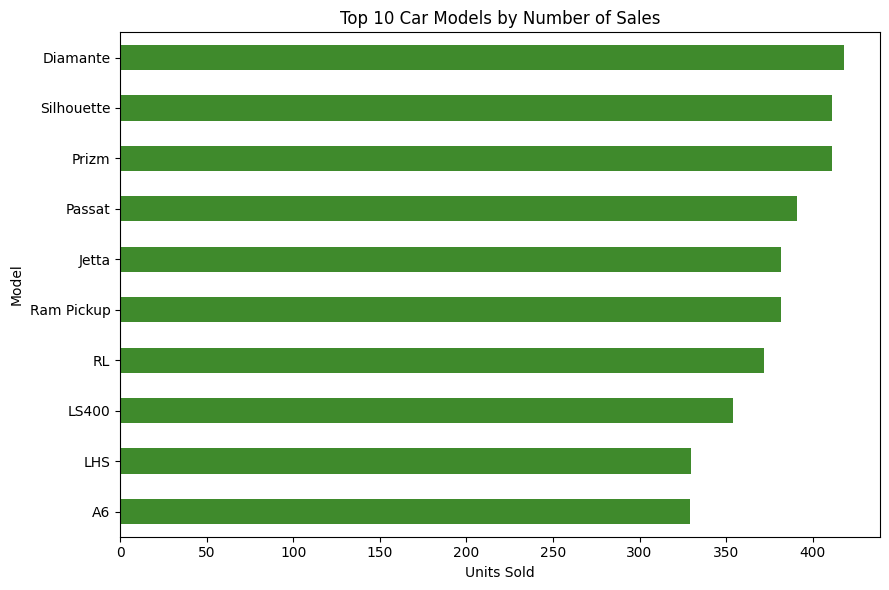

In [32]:
model_sales = eda_df["Model"].value_counts()
display(model_sales.head(10))

model_sales.head(10).sort_values().plot(kind="barh", figsize=(9, 6), color="#3f8a2c")
plt.title("Top 10 Car Models by Number of Sales")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


**Takeaway:** a small set of models drives a disproportionate share of volume — these should get priority floor placement and guaranteed stock levels at every dealer.


### السؤال 3️⃣: ما هو الـ Body Style الأكثر مبيعًا؟ 🚗
**Why it matters:** guides showroom space, floor planning, and supplier negotiation by vehicle category.


,count
Body Style,
SUV,6374
Hatchback,6128
Sedan,4488
Passenger,3945
Hardtop,2970


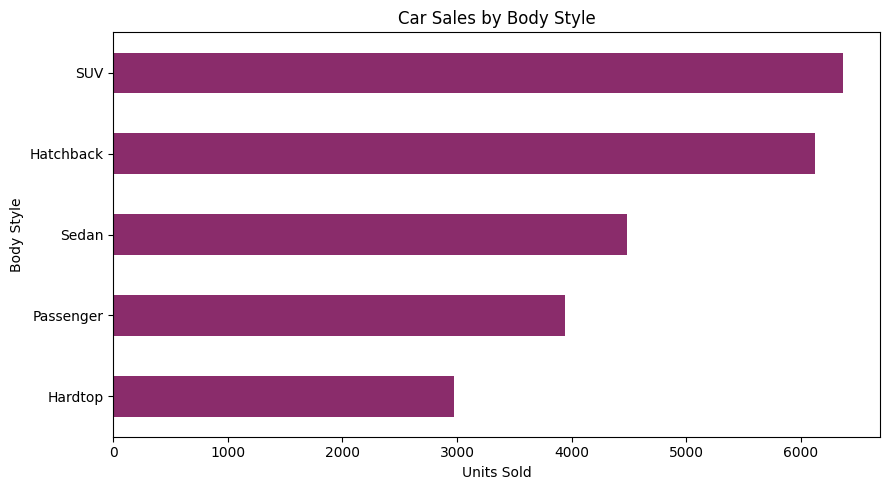

In [33]:
body_style_sales = eda_df["Body Style"].value_counts()
display(body_style_sales)

body_style_sales.sort_values().plot(kind="barh", figsize=(9, 5), color="#8a2c6b")
plt.title("Car Sales by Body Style")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


**Takeaway:** SUVs and Hatchbacks dominate demand — showroom and lot space should be weighted accordingly, and slower-moving body styles reviewed for reduced inventory.


### السؤال 4️⃣: هل الـ Transmission الأكثر انتشارًا هو Automatic أم Manual؟
**Why it matters:** informs procurement mix and can support a "why we don't stock manual" or "why manual is a growth niche" conversation with suppliers.


,count
Transmission,
Auto,12570
Manual,11335


,proportion
Transmission,
Auto,52.58
Manual,47.42


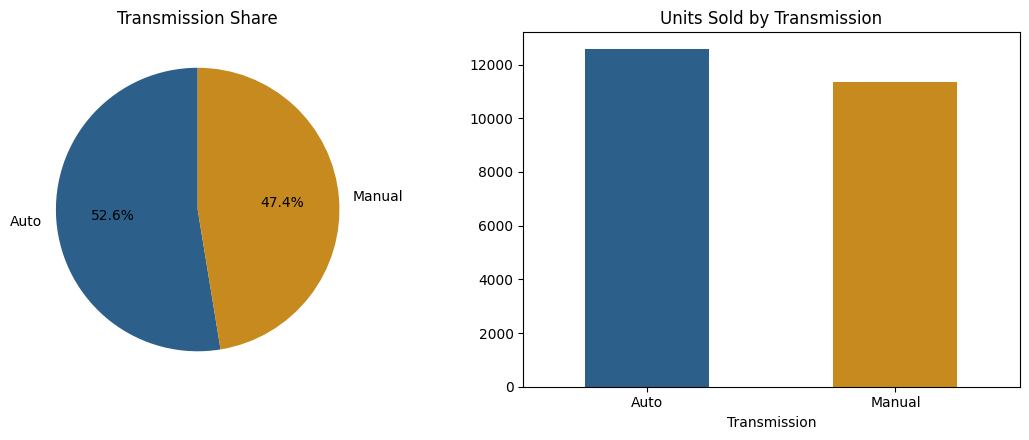

In [34]:
transmission_sales = eda_df["Transmission"].value_counts()
display(transmission_sales)

transmission_pct = eda_df["Transmission"].value_counts(normalize=True).mul(100).round(2)
display(transmission_pct)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
transmission_sales.plot(kind="pie", autopct="%1.1f%%", startangle=90, ax=axes[0], colors=["#2c5f8a", "#c78a1f"])
axes[0].set_ylabel("")
axes[0].set_title("Transmission Share")

transmission_sales.plot(kind="bar", ax=axes[1], color=["#2c5f8a", "#c78a1f"])
axes[1].set_title("Units Sold by Transmission")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


**Takeaway:** the transmission split shows exactly what buyers actually choose — the minority option should not be over-stocked relative to its real demand share.


### السؤال 5️⃣: ما هي أكثر مناطق الـ Dealers مبيعًا؟ 🌍
**Why it matters:** directs regional investment, staffing, and expansion priorities.


,count
Dealer_Region,
Austin,4135
Janesville,3821
Scottsdale,3433
Pasco,3131
Aurora,3129
Greenville,3128
Middletown,3128


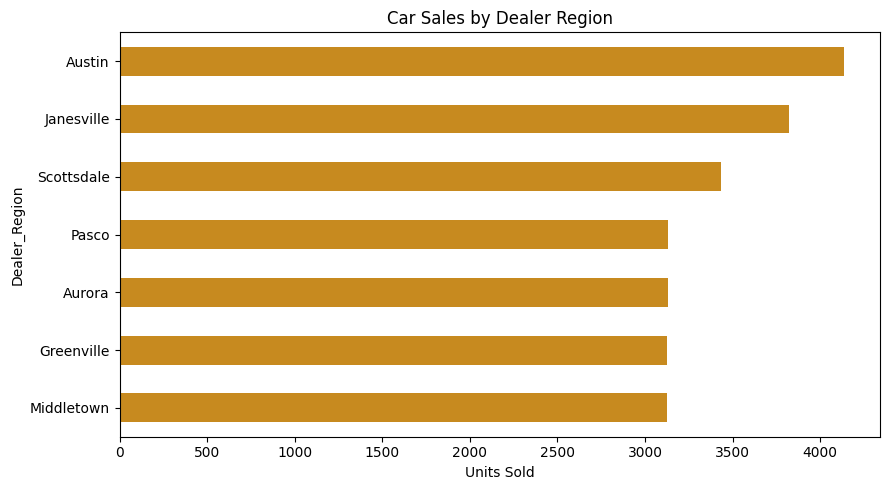

In [35]:
region_sales = eda_df["Dealer_Region"].value_counts()
display(region_sales)

region_sales.sort_values().plot(kind="barh", figsize=(9, 5), color="#c78a1f")
plt.title("Car Sales by Dealer Region")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


**Takeaway:** sales are concentrated in a handful of regions — these are the strongest candidates for opening additional outlets, while lagging regions may need targeted marketing or a performance review.


### السؤال 6️⃣: أي Body Style لديه أعلى متوسط سعر؟ 💰🚗
**Why it matters:** shows which vehicle category to position as the higher-margin, premium offering.


,count,mean,median
Body Style,,,
Sedan,4488,29832.802807,25000.0
Hardtop,2970,29145.760269,24000.0
Passenger,3945,28942.031686,24000.0
Hatchback,6128,27127.035574,22000.0
SUV,6374,26767.673204,22350.0


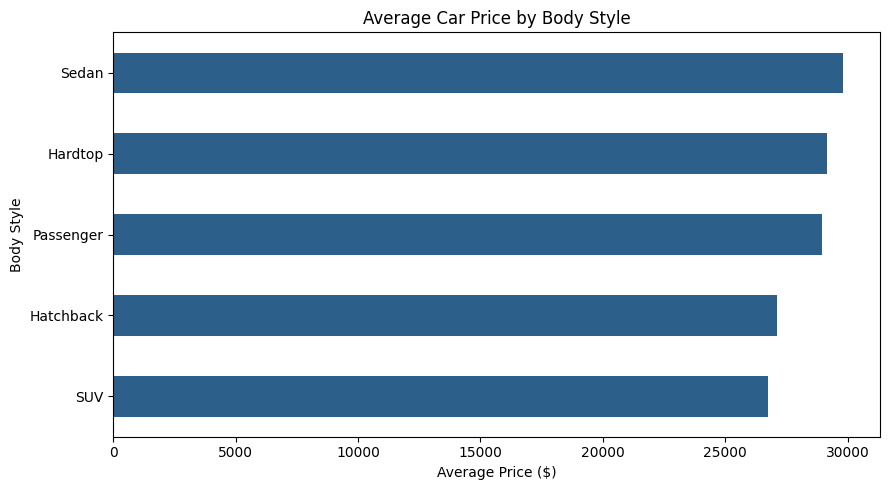

In [36]:
body_style_price = (
    eda_df.groupby("Body Style")["Price ($)"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(body_style_price)

body_style_price["mean"].sort_values().plot(kind="barh", figsize=(9, 5), color="#2c5f8a")
plt.title("Average Car Price by Body Style")
plt.xlabel("Average Price ($)")
plt.tight_layout()
plt.show()


**Takeaway:** the highest-average-price body style is the natural focus for upsell and finance-package offers, since customers already accept a higher price point in that category.


### السؤال 7️⃣: أي شركة لديها أعلى متوسط سعر للسيارات؟
**Why it matters:** identifies which brands are positioned as premium versus volume/value in this network.


,count,mean,median
Company,,,
Cadillac,652,40972.093558,34000.0
Saab,210,36516.338095,27250.0
Lexus,802,34024.567332,27001.0
Buick,439,33634.362187,29000.0
Oldsmobile,1111,31894.250225,26700.0
Lincoln,492,31407.036585,26000.0
Saturn,586,31092.609215,25150.0
Toyota,1110,29513.120721,27000.0
Plymouth,617,29404.980551,22001.0


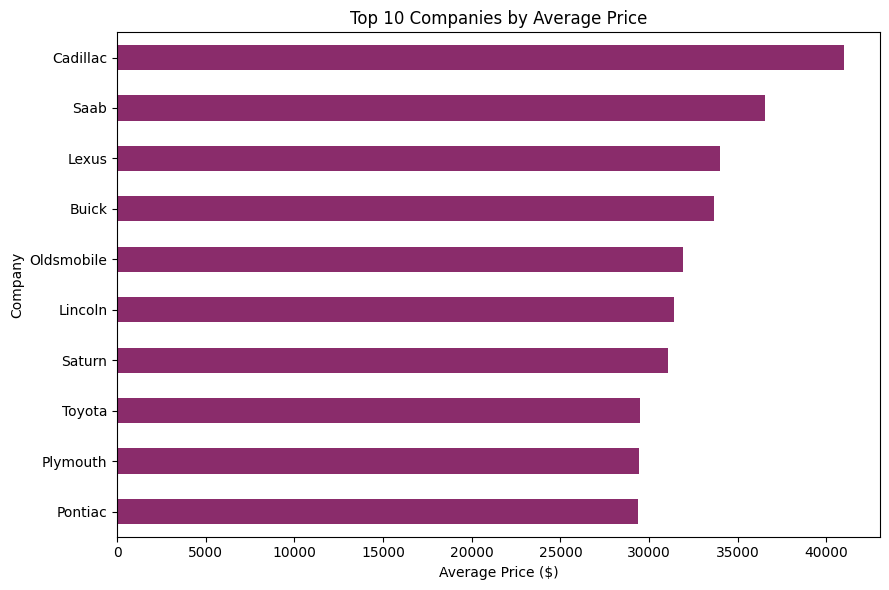

In [37]:
company_price = (
    eda_df.groupby("Company")["Price ($)"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(company_price.head(10))

company_price["mean"].head(10).sort_values().plot(kind="barh", figsize=(9, 6), color="#8a2c6b")
plt.title("Top 10 Companies by Average Price")
plt.xlabel("Average Price ($)")
plt.tight_layout()
plt.show()


**Takeaway:** premium-average-price brands are candidates for higher-touch sales service and financing partnerships; high-volume, lower-average-price brands should be optimized for fast turnover instead.


### السؤال 8️⃣: هل يوجد علاقة بين الدخل السنوي للعميل وسعر السيارة؟
**Why it matters:** tests whether income-based customer segmentation is a useful sales strategy at all.


,Annual Income,Price ($)
Annual Income,1.000000,0.012075
Price ($),0.012075,1.000000


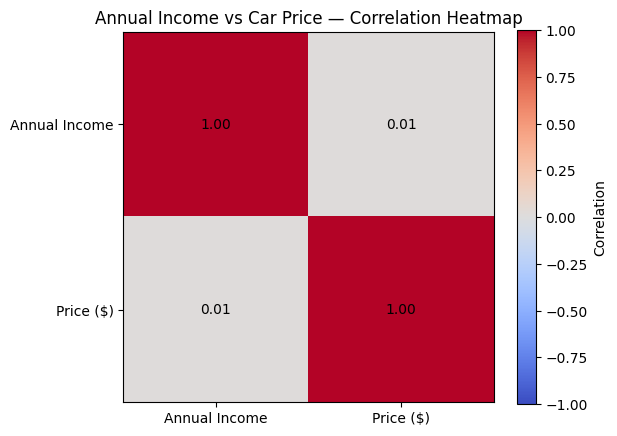

In [38]:
correlation = eda_df[["Annual Income", "Price ($)"]].corr()
display(correlation)

plt.figure(figsize=(6, 4.5))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

for i in range(len(correlation)):
    for j in range(len(correlation)):
        plt.text(
            j, i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

plt.title("Annual Income vs Car Price — Correlation Heatmap")
plt.tight_layout()
plt.show()


**Takeaway:** the correlation is weak (≈0.01), meaning income alone is not a reliable predictor of which price band a customer will buy in this dataset. Sales strategy should not assume "higher income = more expensive car" without further evidence.


### السؤال 9️⃣: هل مبيعات السيارات بتتغير مع الوقت؟
**Why it matters:** reveals seasonality for staffing, promotions, and cash-flow planning.


,Year,Month,Sales,Period
0,2022,1,315,2022-01
1,2022,2,320,2022-02
2,2022,3,705,2022-03
3,2022,4,800,2022-04
4,2022,5,750,2022-05
5,2022,6,690,2022-06
6,2022,7,700,2022-07
7,2022,8,810,2022-08
8,2022,9,1475,2022-09
9,2022,10,835,2022-10


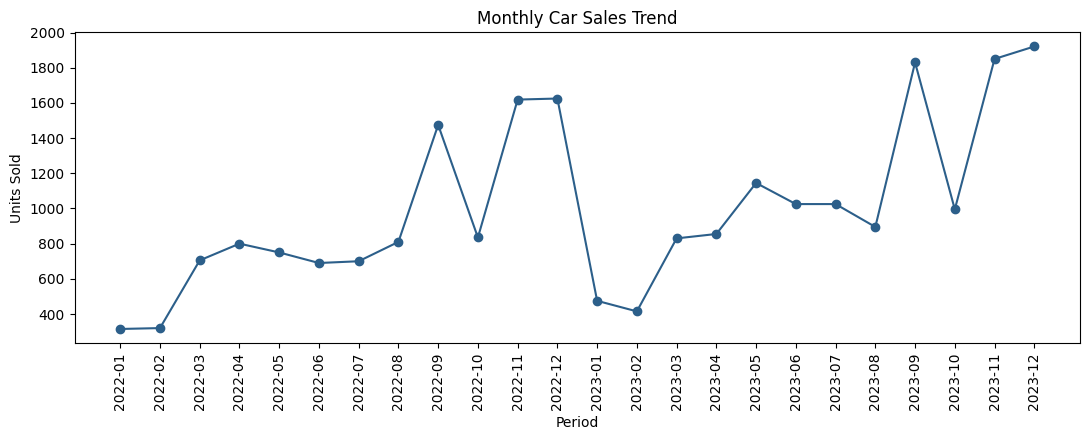

In [39]:
monthly_sales = (
    eda_df.groupby(["Year", "Month"])
    .size()
    .reset_index(name="Sales")
)
monthly_sales["Period"] = (
    monthly_sales["Year"].astype(str) + "-" + monthly_sales["Month"].astype(str).str.zfill(2)
)
display(monthly_sales)

plt.figure(figsize=(11, 4.5))
plt.plot(monthly_sales["Period"], monthly_sales["Sales"], marker="o", color="#2c5f8a")
plt.title("Monthly Car Sales Trend")
plt.xlabel("Period")
plt.ylabel("Units Sold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


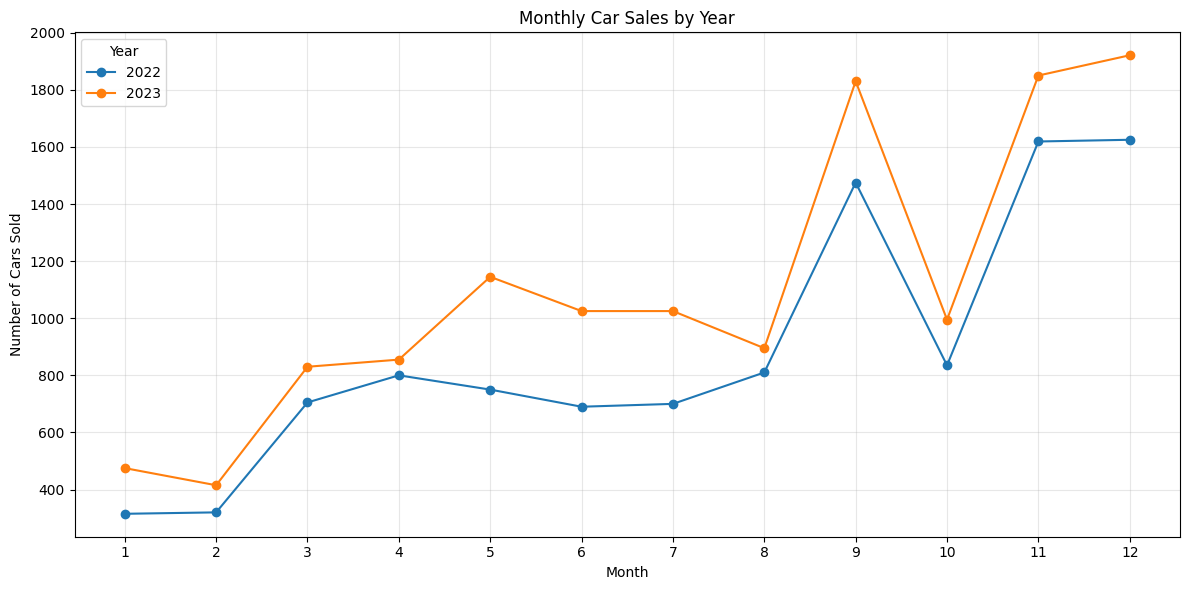

In [40]:
# Year-over-year comparison: does the seasonal pattern repeat every year?
yearly_monthly_sales = (
    eda_df.groupby(["Year", "Month"])
      .size()
      .reset_index(name="Sales")
)

plt.figure(figsize=(12, 6))

for year in sorted(yearly_monthly_sales["Year"].unique()):
    data = yearly_monthly_sales[
        yearly_monthly_sales["Year"] == year
    ]

    plt.plot(
        data["Month"],
        data["Sales"],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Car Sales by Year")
plt.xlabel("Month")
plt.ylabel("Number of Cars Sold")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Takeaway:** clear month-to-month variation supports planning promotions and staffing around the historically stronger months. Comparing the years on the same month axis also shows whether the seasonal pattern repeats every year or whether a given month's strength/weakness was a one-off — the former justifies a fixed promotional calendar, the latter needs further investigation.


### السؤال 🔟: أي شركة لديها أعلى إجمالي قيمة مبيعات (Revenue)؟
**Why it matters:** volume leaders and revenue leaders are not always the same brand — this identifies where the actual money is made.


,units,total_revenue,avg_price
Company,,,
Chevrolet,1819,47655265,26198.606377
Ford,1614,47231583,29263.682156
Dodge,1670,44079996,26395.207186
Oldsmobile,1111,35434512,31894.250225
Mercedes-B,1285,34624123,26944.842802
Volkswagen,1333,34082881,25568.552888
Mitsubishi,1277,34062466,26673.818324
Toyota,1110,32759564,29513.120721
Chrysler,1120,29141873,26019.529464


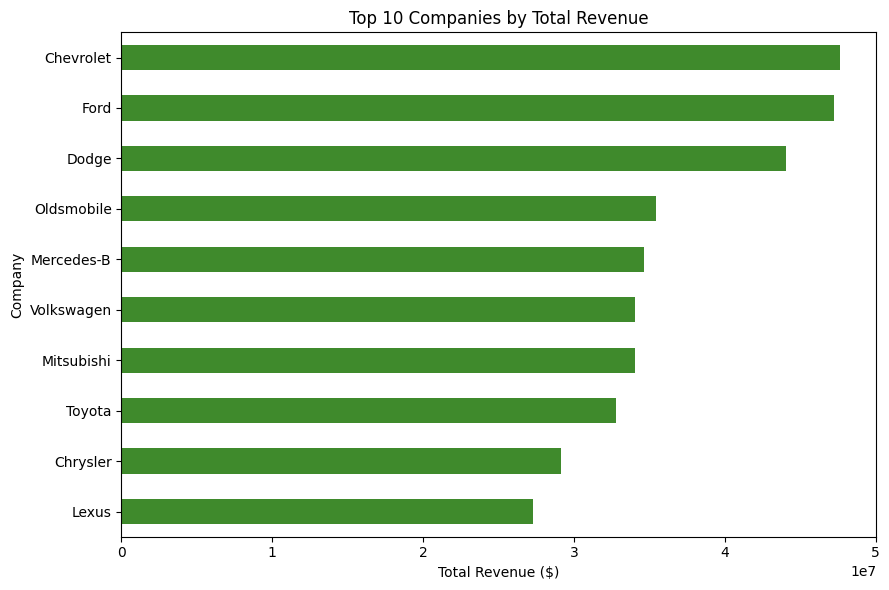

In [41]:
company_total_sales = (
    eda_df.groupby("Company")["Price ($)"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)
company_total_sales = company_total_sales.rename(columns={"count": "units", "sum": "total_revenue", "mean": "avg_price"})
display(company_total_sales.head(10))

company_total_sales["total_revenue"].head(10).sort_values().plot(kind="barh", figsize=(9, 6), color="#3f8a2c")
plt.title("Top 10 Companies by Total Revenue")
plt.xlabel("Total Revenue ($)")
plt.tight_layout()
plt.show()


**Takeaway:** compare this ranking with Question 1 (units sold) — a brand can rank lower in units but higher in revenue due to a higher average price, which changes which brand actually deserves the biggest share of marketing investment.


---
## 10. Consolidated Insights


In [42]:
insights = [
    ["Data Quality", "Minimal missing values", f"{eda_df.isna().sum().sum()} missing cells after cleaning", "Low risk to analysis", "Continue automated validation", "High"],
    ["Data Quality", "Sample size", f"{len(eda_df):,} rows", "Large enough for robust segment analysis", "Maintain data pipeline", "High"],
    ["Technical", "Right-skewed price", f"Skew={eda_df['Price ($)'].skew():.2f}", "Mean is tail-sensitive", "Report median alongside mean", "Medium"],
    ["Technical", "Right-skewed income", f"Skew={eda_df['Annual Income'].skew():.2f}", "A few high-income customers pull the average up", "Use median for headline reporting", "Medium"],
    ["Technical", "Income-price relationship", f"Pearson={pearson_income_price:.2f}", "Income is a weak standalone price predictor", "Avoid income-only segmentation", "Medium"],
    ["Business", "Top company by units", f"{company_sales.index[0]}: {int(company_sales.iloc[0]):,} units", "Clear volume leader", "Protect stock levels", "High"],
    ["Business", "Top company by revenue", f"{company_total_sales.index[0]}: ${company_total_sales['total_revenue'].iloc[0]:,.0f}", "Revenue leader may differ from volume leader", "Align marketing budget with revenue, not just units", "High"],
    ["Business", "Dominant body style", f"{body_style_sales.index[0]}: {int(body_style_sales.iloc[0]):,} units", "Core inventory category", "Prioritize showroom space", "High"],
    ["Business", "Highest-priced body style", f"{body_style_price.index[0]}: ${body_style_price['mean'].iloc[0]:,.0f} avg", "Premium/upsell opportunity", "Target finance offers here", "Medium"],
    ["Operational", "Leading region", f"{region_sales.index[0]}: {int(region_sales.iloc[0]):,} units", "Concentration of demand", "Consider regional expansion", "High"],
    ["Operational", "Transmission split", f"{transmission_pct.to_dict()}", "Shows real buyer preference", "Match procurement to actual demand", "Medium"],
    ["Risk", "Fairness", "Gender/Income are non-controllable customer attributes", "Risk of discriminatory pricing if misused", "Use for audit only, not targeting", "High"],
    ["Risk", "No causal proof", "Observational sales log", "Associations may be confounded by region/dealer mix", "Validate with controlled tests before major decisions", "High"],
]
insights_df = pd.DataFrame(insights, columns=["category", "insight", "evidence", "business_impact", "recommended_action", "priority"])
display(insights_df)
print("Insight count:", len(insights_df))


,category,insight,evidence,business_impact,recommended_action,priority
0,Data Quality,Minimal missing values,0 missing cells after cleaning,Low risk to analysis,Continue automated validation,High
1,Data Quality,Sample size,"23,905 rows",Large enough for robust segment analysis,Maintain data pipeline,High
2,Technical,Right-skewed price,Skew=1.47,Mean is tail-sensitive,Report median alongside mean,Medium
3,Technical,Right-skewed income,Skew=1.74,A few high-income customers pull the average up,Use median for headline reporting,Medium
4,Technical,Income-price relationship,Pearson=0.01,Income is a weak standalone price predictor,Avoid income-only segmentation,Medium
5,Business,Top company by units,"Chevrolet: 1,819 units",Clear volume leader,Protect stock levels,High
6,Business,Top company by revenue,"Chevrolet: $47,655,265",Revenue leader may differ from volume leader,"Align marketing budget with revenue, not just ...",High
7,Business,Dominant body style,"SUV: 6,374 units",Core inventory category,Prioritize showroom space,High
8,Business,Highest-priced body style,"Sedan: $29,833 avg",Premium/upsell opportunity,Target finance offers here,Medium
9,Operational,Leading region,"Austin: 4,135 units",Concentration of demand,Consider regional expansion,High


Insight count: 13


## Executive Report


In [43]:
print(f"""PROJECT OVERVIEW
Analyzed {len(eda_df):,} car sale transactions across {eda_df['Company'].nunique()} companies, {eda_df['Model'].nunique()} models, and {eda_df['Dealer_Region'].nunique()} regions.

DATASET SUMMARY
Sixteen raw fields, minimal missing values, clean category labels, and a date range from {eda_df['Date'].min().date()} to {eda_df['Date'].max().date()}.

MAJOR FINDINGS
- Total revenue: ${total_revenue:,.0f}
- Average price: ${avg_price:,.0f} (median: ${median_price:,.0f})
- Top company by units: {company_sales.index[0]} ({int(company_sales.iloc[0]):,} units)
- Top company by revenue: {company_total_sales.index[0]} (${company_total_sales['total_revenue'].iloc[0]:,.0f})
- Dominant body style: {body_style_sales.index[0]}
- Highest-priced body style: {body_style_price.index[0]} (avg ${body_style_price['mean'].iloc[0]:,.0f})
- Leading region: {region_sales.index[0]}
- Income-price correlation: {pearson_income_price:.2f} (weak)

RECOMMENDATIONS
1. Protect and prioritize stock for the top-volume brands and models identified above.
2. Track revenue leaders separately from volume leaders when allocating marketing budget.
3. Weight showroom space and inventory toward the dominant body style and region.
4. Use the highest-priced body style for upsell and financing offers.
5. Do not rely on customer income alone to predict or steer price segment; validate any income-based targeting with further analysis.

RISKS AND LIMITATIONS
Observational sales data only; no causal proof behind any pattern. Regional and dealer imbalance may confound simple rankings. Gender and income are sensitive fields and must be restricted to audit use, never differential pricing.

FUTURE WORK
Add dealer-level cost data to compute margin (not just revenue), build a price-prediction model with proper leakage controls, and monitor month-over-month trends for early warning of demand shifts.
""")


PROJECT OVERVIEW
Analyzed 23,905 car sale transactions across 30 companies, 154 models, and 7 regions.

DATASET SUMMARY
Sixteen raw fields, minimal missing values, clean category labels, and a date range from 2022-01-02 to 2023-12-31.

MAJOR FINDINGS
- Total revenue: $671,480,465
- Average price: $28,090 (median: $23,000)
- Top company by units: Chevrolet (1,819 units)
- Top company by revenue: Chevrolet ($47,655,265)
- Dominant body style: SUV
- Highest-priced body style: Sedan (avg $29,833)
- Leading region: Austin
- Income-price correlation: 0.01 (weak)

RECOMMENDATIONS
1. Protect and prioritize stock for the top-volume brands and models identified above.
2. Track revenue leaders separately from volume leaders when allocating marketing budget.
3. Weight showroom space and inventory toward the dominant body style and region.
4. Use the highest-priced body style for upsell and financing offers.
5. Do not rely on customer income alone to predict or steer price segment; validate any inc

---
# Final Conclusion

The dataset is well-structured and suitable for driving real business decisions on inventory, regional investment, and pricing strategy. The ten business questions above give the owner a decision-ready view of the network's performance; the highest-value next step is adding cost/margin data so revenue leadership can be translated into profitability leadership.
